In [11]:
# ================================
# PHASE 7.1 — SANITY CHECK (STEP 1)
# Basic structural + consistency checks
# ================================

import pandas as pd

# --------- CHANGE THESE PATHS ----------
label_path = r"C:\Users\deep8\breast_cancer_project_folder\drug_subtype_labels.csv"
feature_all_path = r"C:\Users\deep8\breast_cancer_project_folder\features_all.csv"
network_feat_path = r"C:\Users\deep8\breast_cancer_project_folder\phase6_network_features_final.csv"
drug_map_path = r"C:\Users\deep8\breast_cancer_project_folder\Phase6_ChEMBL_Drug_Name_Map.csv"
# --------------------------------------

# ================================
# LOAD DATA
# ================================
labels = pd.read_csv(label_path)
feat_pathway = pd.read_csv(feature_all_path)
feat_network = pd.read_csv(network_feat_path)
drug_map = pd.read_csv(drug_map_path)

print("✅ Files loaded successfully\n")

# ================================
# 1. BASIC OVERVIEW
# ================================
def overview(df, name):
    print(f"--- {name} ---")
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    print()

overview(labels, "LABEL FILE")
overview(feat_pathway, "PATHWAY FEATURES")
overview(feat_network, "NETWORK FEATURES")
overview(drug_map, "DRUG MAP")

# ================================
# 2. COLUMN PRESENCE CHECK
# ================================
required_label_cols = ["drug_id", "subtype", "final_label"]
missing_cols = set(required_label_cols) - set(labels.columns)
print("Missing label columns:", missing_cols if missing_cols else "None")

# ================================
# 3. SUBTYPE CONSISTENCY CHECK
# ================================
print("\nUnique subtypes:")
print("Labels   :", sorted(labels["subtype"].dropna().unique()))
print("\nPathway feature subtype columns detected:")
print([c for c in feat_pathway.columns if "_luma" in c or "_lumb" in c or "_her2" in c or "_tnbc" in c])
print("Network  :", sorted(feat_network["subtype"].dropna().unique()))

# ================================
# 4. DRUG ID CONSISTENCY CHECK
# ================================

network_drugs = set(feat_network["chembl_id"].dropna().unique())

print("\nDrug ID overlap check:")
print("Drugs in labels but NOT in network features:",
      len(label_drugs - network_drugs))
print("Drugs in network features but NOT in labels:",
      len(network_drugs - label_drugs))

# ================================
# 5. DUPLICATE CHECK
# ================================
print("\nDuplicate rows check:")
print("Label duplicates (drug_id, subtype):",
      labels.duplicated(subset=["drug_id", "subtype"]).sum())

print("Network duplicates (chembl_id, subtype):",
      feat_network.duplicated(subset=["chembl_id", "subtype"]).sum())

print("Pathway duplicates (drug_id, subtype) [if applicable]:",
      feat_pathway.duplicated().sum())

# ================================
# 6. MISSING VALUE CHECK
# ================================
print("\nMissing values summary:")

print("\nLabels:")
print(labels.isna().sum())

print("\nPathway features:")
print(feat_pathway.isna().sum())

print("\nNetwork features:")
print(feat_network.isna().sum())

# ================================
# 7. CLASS BALANCE CHECK
# ================================
print("\nClass balance per subtype:")
class_balance = (
    labels
    .groupby("subtype")["final_label"]
    .value_counts()
    .unstack(fill_value=0)
)
print(class_balance)
# Fix column name
labels = labels.rename(columns={"Drug ID": "drug_id"})

# Normalize subtype names
labels["subtype"] = labels["subtype"].str.upper().str.strip()
feat_network["subtype"] = feat_network["subtype"].str.upper().str.strip()

print("Subtype columns in pathway features:")
print([c for c in feat_pathway.columns if any(x in c for x in ["luma","lumb","her2","tnbc"])])

print("\n✅ Sanity check step 1 completed.")


✅ Files loaded successfully

--- LABEL FILE ---
Shape: (1072, 5)
Columns: ['Drug ID', 'drug_name', 'subtype', 'final_label', 'final_confidence']

--- PATHWAY FEATURES ---
Shape: (510, 17)
Columns: ['drug', 'n_pathways_luma', 'mean_pathway_score_luma', 'max_pathway_score_luma', 'sum_pathway_score_luma', 'n_pathways_lumb', 'mean_pathway_score_lumb', 'max_pathway_score_lumb', 'sum_pathway_score_lumb', 'n_pathways_her2', 'mean_pathway_score_her2', 'max_pathway_score_her2', 'sum_pathway_score_her2', 'n_pathways_tnbc', 'mean_pathway_score_tnbc', 'max_pathway_score_tnbc', 'sum_pathway_score_tnbc']

--- NETWORK FEATURES ---
Shape: (2088, 6)
Columns: ['chembl_id', 'mean_target_pagerank', 'max_target_pagerank', 'n_targets_in_network', 'network_coverage', 'subtype']

--- DRUG MAP ---
Shape: (49114, 3)
Columns: ['chembl_id', 'drug_name', 'drug_name_clean']

Missing label columns: {'drug_id'}

Unique subtypes:
Labels   : ['HER2', 'LUMA', 'LUMB', 'TNBC']

Pathway feature subtype columns detected:
['

NameError: name 'label_drugs' is not defined

In [9]:


# ================================
# PHASE 7.1 — SANITY CHECK (FIXED)
# ================================

import pandas as pd

# --------- PATHS ----------
label_path = r"C:\Users\deep8\breast_cancer_project_folder\drug_subtype_labels.csv"
feature_all_path = r"C:\Users\deep8\breast_cancer_project_folder\features_all.csv"
network_feat_path = r"C:\Users\deep8\breast_cancer_project_folder\phase6_network_features_final.csv"
drug_map_path = r"C:\Users\deep8\breast_cancer_project_folder\Phase6_ChEMBL_Drug_Name_Map.csv"
# --------------------------

# Load
labels = pd.read_csv(label_path)
feat_pathway = pd.read_csv(feature_all_path)
feat_network = pd.read_csv(network_feat_path)
drug_map = pd.read_csv(drug_map_path)

print("✅ Files loaded successfully\n")

# ================================
# 1. FIX COLUMN NAMES
# ================================
labels = labels.rename(columns={"Drug ID": "drug_id"})

# ================================
# 2. STANDARDIZE SUBTYPES
# ================================
subtype_map = {
    "LUMA": "LUMINAL_A",
    "LUMB": "LUMINAL_B",
    "Luminal A": "LUMINAL_A",
    "Luminal B": "LUMINAL_B",
    "HER2": "HER2",
    "TNBC": "TNBC"
}

labels["subtype"] = labels["subtype"].map(subtype_map)
feat_network["subtype"] = feat_network["subtype"].map(subtype_map)

# ================================
# 3. BASIC OVERVIEW
# ================================
def overview(df, name):
    print(f"--- {name} ---")
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    print()

overview(labels, "LABEL FILE")
overview(feat_pathway, "PATHWAY FEATURES")
overview(feat_network, "NETWORK FEATURES")

# ================================
# 4. DRUG ID CONSISTENCY
# ================================
label_drugs = set(labels["drug_id"].dropna().unique())
network_drugs = set(feat_network["chembl_id"].dropna().unique())

print("\nDrug ID overlap check:")
print("Labels NOT in network:", len(label_drugs - network_drugs))
print("Network NOT in labels:", len(network_drugs - label_drugs))

# ================================
# 5. DUPLICATES
# ================================
print("\nDuplicate rows:")
print("Labels:", labels.duplicated(["drug_id", "subtype"]).sum())
print("Network:", feat_network.duplicated(["chembl_id", "subtype"]).sum())

# ================================
# 6. CLASS BALANCE
# ================================
print("\nClass balance per subtype:")
print(
    labels.groupby("subtype")["final_label"]
    .value_counts()
    .unstack(fill_value=0)
)

print("\n✅ Sanity check fixed and completed")


✅ Files loaded successfully

--- LABEL FILE ---
Shape: (1072, 5)
Columns: ['drug_id', 'drug_name', 'subtype', 'final_label', 'final_confidence']

--- PATHWAY FEATURES ---
Shape: (510, 17)
Columns: ['drug', 'n_pathways_luma', 'mean_pathway_score_luma', 'max_pathway_score_luma', 'sum_pathway_score_luma', 'n_pathways_lumb', 'mean_pathway_score_lumb', 'max_pathway_score_lumb', 'sum_pathway_score_lumb', 'n_pathways_her2', 'mean_pathway_score_her2', 'max_pathway_score_her2', 'sum_pathway_score_her2', 'n_pathways_tnbc', 'mean_pathway_score_tnbc', 'max_pathway_score_tnbc', 'sum_pathway_score_tnbc']

--- NETWORK FEATURES ---
Shape: (2088, 6)
Columns: ['chembl_id', 'mean_target_pagerank', 'max_target_pagerank', 'n_targets_in_network', 'network_coverage', 'subtype']


Drug ID overlap check:
Labels NOT in network: 292
Network NOT in labels: 522

Duplicate rows:
Labels: 28
Network: 0

Class balance per subtype:
final_label    0   1
subtype             
HER2         233  23
LUMINAL_A    251  17
LUMI

In [11]:


# ================================
# PHASE 7.2 — STEP 1
# Deduplicate label file
# ================================

# Keep highest-confidence label per (drug_id, subtype)
labels_clean = (
    labels
    .sort_values("final_confidence", ascending=False)
    .drop_duplicates(subset=["drug_id", "subtype"], keep="first")
    .reset_index(drop=True)
)

print("Before deduplication:", labels.shape)
print("After deduplication :", labels_clean.shape)

# Verify duplicates removed
print(
    "Remaining duplicates:",
    labels_clean.duplicated(["drug_id", "subtype"]).sum()
)


Before deduplication: (1072, 5)
After deduplication : (1044, 5)
Remaining duplicates: 0


In [13]:
## 🧪 PHASE 7.2 — STEP 2 CODE (RUN NEXT)

# ================================
# PHASE 7.2 — STEP 2
# Reshape pathway features (wide → long)
# ================================

import pandas as pd

# Rename drug column for consistency
feat_pathway_long = feat_pathway.rename(columns={"drug": "drug_id"})

# Define subtype mappings
subtype_suffix_map = {
    "luma": "LUMINAL_A",
    "lumb": "LUMINAL_B",
    "her2": "HER2",
    "tnbc": "TNBC"
}

long_frames = []

for suffix, subtype in subtype_suffix_map.items():
    cols = [
        f"n_pathways_{suffix}",
        f"mean_pathway_score_{suffix}",
        f"max_pathway_score_{suffix}",
        f"sum_pathway_score_{suffix}"
    ]
    
    temp = feat_pathway_long[["drug_id"] + cols].copy()
    temp.columns = ["drug_id", "n_pathways", "mean_pathway_score",
                    "max_pathway_score", "sum_pathway_score"]
    temp["subtype"] = subtype
    
    long_frames.append(temp)

# Combine all subtypes
feat_pathway_long = pd.concat(long_frames, ignore_index=True)

# Final column order
feat_pathway_long = feat_pathway_long[
    ["drug_id", "subtype", "n_pathways",
     "mean_pathway_score", "max_pathway_score", "sum_pathway_score"]
]

print("Pathway features reshaped successfully")
print("Shape:", feat_pathway_long.shape)
print(feat_pathway_long.head())


Pathway features reshaped successfully
Shape: (2040, 6)
      drug_id    subtype  n_pathways  mean_pathway_score  max_pathway_score  \
0  CHEMBL1778  LUMINAL_A          16            0.054038           0.153784   
1  CHEMBL1782  LUMINAL_A           5            0.015057           0.045174   
2  CHEMBL1783  LUMINAL_A          29            0.046635           0.153784   
3  CHEMBL1785  LUMINAL_A          10            0.041135           0.153784   
4  CHEMBL1786  LUMINAL_A           2            0.023320           0.045174   

   sum_pathway_score  
0           0.864616  
1           0.075286  
2           1.352424  
3           0.411352  
4           0.046641  


In [15]:

# ================================
# PHASE 7.2 — STEP 3
# Merge pathway + network features
# ================================

# Rename for consistency
feat_network_merge = feat_network.rename(columns={"chembl_id": "drug_id"})

# Select only needed network columns
feat_network_merge = feat_network_merge[
    ["drug_id", "subtype",
     "mean_target_pagerank",
     "max_target_pagerank",
     "n_targets_in_network",
     "network_coverage"]
]

# Inner join on (drug_id, subtype)
features_merged = pd.merge(
    feat_pathway_long,
    feat_network_merge,
    on=["drug_id", "subtype"],
    how="inner"
)

print("Merged feature table created")
print("Shape:", features_merged.shape)
print(features_merged.head())


Merged feature table created
Shape: (2040, 10)
      drug_id    subtype  n_pathways  mean_pathway_score  max_pathway_score  \
0  CHEMBL1778  LUMINAL_A          16            0.054038           0.153784   
1  CHEMBL1782  LUMINAL_A           5            0.015057           0.045174   
2  CHEMBL1783  LUMINAL_A          29            0.046635           0.153784   
3  CHEMBL1785  LUMINAL_A          10            0.041135           0.153784   
4  CHEMBL1786  LUMINAL_A           2            0.023320           0.045174   

   sum_pathway_score  mean_target_pagerank  max_target_pagerank  \
0           0.864616              0.000302             0.000302   
1           0.075286              0.000091             0.000091   
2           1.352424              0.000768             0.000768   
3           0.411352              0.000129             0.000129   
4           0.046641              0.000024             0.000024   

   n_targets_in_network  network_coverage  
0                     1        

In [17]:

print("Labels drug_id dtype :", labels_clean["drug_id"].dtype)
print("Features drug_id dtype:", features_merged["drug_id"].dtype)

print("\nSample label drug_ids:")
print(labels_clean["drug_id"].head())

print("\nSample feature drug_ids:")
print(features_merged["drug_id"].head())


Labels drug_id dtype : int64
Features drug_id dtype: object

Sample label drug_ids:
0    1003
1    1832
2    1828
3    1829
4    1829
Name: drug_id, dtype: int64

Sample feature drug_ids:
0    CHEMBL1778
1    CHEMBL1782
2    CHEMBL1783
3    CHEMBL1785
4    CHEMBL1786
Name: drug_id, dtype: object


In [19]:
# ================================
# FIX drug_id FORMAT IN LABELS
# ================================

labels_clean["drug_id"] = (
    "CHEMBL" + labels_clean["drug_id"].astype(str)
)

print("Fixed label drug_id examples:")
print(labels_clean["drug_id"].head())

print("New dtype:", labels_clean["drug_id"].dtype)


Fixed label drug_id examples:
0    CHEMBL1003
1    CHEMBL1832
2    CHEMBL1828
3    CHEMBL1829
4    CHEMBL1829
Name: drug_id, dtype: object
New dtype: object


In [21]:
# ================================
# PHASE 7.2 — STEP 4 (FIXED)
# Attach labels
# ================================

labels_for_merge = labels_clean[
    ["drug_id", "subtype", "final_label"]
]

ml_df = pd.merge(
    features_merged,
    labels_for_merge,
    on=["drug_id", "subtype"],
    how="inner"
)

print("✅ Final ML table created")
print("Shape:", ml_df.shape)
print(ml_df.head())

# Final sanity checks
print("\nMissing labels:", ml_df["final_label"].isna().sum())
print("Duplicate rows:",
      ml_df.duplicated(["drug_id", "subtype"]).sum())


✅ Final ML table created
Shape: (208, 11)
      drug_id    subtype  n_pathways  mean_pathway_score  max_pathway_score  \
0  CHEMBL1778  LUMINAL_A          16            0.054038           0.153784   
1  CHEMBL1782  LUMINAL_A           5            0.015057           0.045174   
2  CHEMBL1783  LUMINAL_A          29            0.046635           0.153784   
3  CHEMBL1785  LUMINAL_A          10            0.041135           0.153784   
4  CHEMBL1786  LUMINAL_A           2            0.023320           0.045174   

   sum_pathway_score  mean_target_pagerank  max_target_pagerank  \
0           0.864616              0.000302             0.000302   
1           0.075286              0.000091             0.000091   
2           1.352424              0.000768             0.000768   
3           0.411352              0.000129             0.000129   
4           0.046641              0.000024             0.000024   

   n_targets_in_network  network_coverage  final_label  
0                     1

In [23]:
ml_df.groupby("subtype")["final_label"].value_counts().unstack(fill_value=0)


final_label,0,1
subtype,,
HER2,47,3
LUMINAL_A,50,2
LUMINAL_B,53,1
TNBC,50,2


In [31]:
# PHASE 7.3 — Logistic Regression Baseline (TNBC)
## Step 1: Prepare data + LODO CV + ROC/PR + Confusion Matrix


In [25]:
import numpy as np
import pandas as pd

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc,
    roc_curve, confusion_matrix
)

# ================================
# 1) Filter TNBC
# ================================
df = ml_df[ml_df["subtype"] == "TNBC"].copy()

feature_cols = [
    "n_pathways",
    "mean_pathway_score",
    "max_pathway_score",
    "sum_pathway_score",
    "mean_target_pagerank",
    "max_target_pagerank",
    "n_targets_in_network",
    "network_coverage"
]

X = df[feature_cols].values
y = df["final_label"].values
groups = df["drug_id"].values  # LODO groups

print("TNBC samples:", len(df))
print("Positives:", y.sum(), "Negatives:", (y == 0).sum())

# ================================
# 2) LODO Cross-Validation
# ================================
logo = LeaveOneGroupOut()

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        penalty="l2",
        class_weight="balanced",
        solver="liblinear",
        max_iter=200
    ))
])

y_true_all = []
y_prob_all = []

for train_idx, test_idx in logo.split(X, y, groups):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    pipe.fit(X_train, y_train)
    prob = pipe.predict_proba(X_test)[:, 1]

    y_true_all.extend(y_test.tolist())
    y_prob_all.extend(prob.tolist())

y_true_all = np.array(y_true_all)
y_prob_all = np.array(y_prob_all)

# ================================
# 3) Metrics
# ================================
roc_auc = roc_auc_score(y_true_all, y_prob_all)

prec, rec, thr = precision_recall_curve(y_true_all, y_prob_all)
pr_auc = auc(rec, prec)

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC : {pr_auc:.3f}")

# ================================
# 4) Precision@K
# ================================
def precision_at_k(y_true, y_score, k):
    idx = np.argsort(y_score)[::-1][:k]
    return y_true[idx].sum() / k

for k in [5, 10]:
    print(f"Precision@{k}: {precision_at_k(y_true_all, y_prob_all, k):.3f}")

# ================================
# 5) Confusion Matrix (best F1 threshold)
# ================================
f1_scores = (2 * prec * rec) / (prec + rec + 1e-9)
best_thr = thr[np.nanargmax(f1_scores[:-1])]  # align sizes

y_pred = (y_prob_all >= best_thr).astype(int)
cm = confusion_matrix(y_true_all, y_pred)

print("\nChosen threshold (max F1):", round(best_thr, 4))
print("Confusion Matrix:\n", cm)

# ================================
# 6) ROC / PR curve points
# ================================
fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)

print("\nReady for plotting ROC and PR curves.")


TNBC samples: 52
Positives: 2 Negatives: 50
ROC-AUC: 0.870
PR-AUC : 0.119
Precision@5: 0.000
Precision@10: 0.200

Chosen threshold (max F1): 0.656
Confusion Matrix:
 [[42  8]
 [ 0  2]]

Ready for plotting ROC and PR curves.


# PHASE 7.4 — PAN-SUBTYPE LOGISTIC REGRESSION (ONE MODEL)

In [27]:

import numpy as np
import pandas as pd

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc, roc_curve
)

# -----------------------------
# 1) Prepare data (ALL subtypes)
# -----------------------------
df = ml_df.copy()

num_features = [
    "n_pathways",
    "mean_pathway_score",
    "max_pathway_score",
    "sum_pathway_score",
    "mean_target_pagerank",
    "max_target_pagerank",
    "n_targets_in_network",
    "network_coverage"
]

cat_features = ["subtype"]

X = df[num_features + cat_features]
y = df["final_label"].values
groups = df["drug_id"].values  # LODO groups

print("Total samples:", len(df))
print("Total positives:", y.sum(), "Total negatives:", (y==0).sum())
print("Positives by subtype:")
print(df.groupby("subtype")["final_label"].sum())

# -----------------------------
# 2) Preprocess + model
# -----------------------------
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first"), cat_features),
    ]
)

pipe = Pipeline([
    ("prep", preprocess),
    ("lr", LogisticRegression(
        penalty="l2",
        class_weight="balanced",
        solver="liblinear",
        max_iter=300
    ))
])

# -----------------------------
# 3) LODO CV
# -----------------------------
logo = LeaveOneGroupOut()

y_true_all, y_prob_all = [], []
subtype_all = []

for train_idx, test_idx in logo.split(X, y, groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    pipe.fit(X_train, y_train)
    prob = pipe.predict_proba(X_test)[:, 1]

    y_true_all.extend(y_test.tolist())
    y_prob_all.extend(prob.tolist())
    subtype_all.extend(X_test["subtype"].tolist())

y_true_all = np.array(y_true_all)
y_prob_all = np.array(y_prob_all)
subtype_all = np.array(subtype_all)

# -----------------------------
# 4) Metrics (overall)
# -----------------------------
roc_auc = roc_auc_score(y_true_all, y_prob_all)
prec, rec, _ = precision_recall_curve(y_true_all, y_prob_all)
pr_auc = auc(rec, prec)

print(f"\nOVERALL ROC-AUC: {roc_auc:.3f}")
print(f"OVERALL PR-AUC : {pr_auc:.3f}")

# -----------------------------
# 5) Per-subtype ROC-AUC
# -----------------------------
print("\nROC-AUC by subtype:")
for st in np.unique(subtype_all):
    idx = subtype_all == st
    if y_true_all[idx].sum() > 0:
        auc_st = roc_auc_score(y_true_all[idx], y_prob_all[idx])
        print(f"{st:10s}: {auc_st:.3f}")
    else:
        print(f"{st:10s}: NA (no positives)")

print("\nPan-subtype model ready.")


Total samples: 208
Total positives: 8 Total negatives: 200
Positives by subtype:
subtype
HER2         3
LUMINAL_A    2
LUMINAL_B    1
TNBC         2
Name: final_label, dtype: int64

OVERALL ROC-AUC: 0.774
OVERALL PR-AUC : 0.094

ROC-AUC by subtype:
HER2      : 0.865
LUMINAL_A : 0.500
LUMINAL_B : 0.736
TNBC      : 0.880

Pan-subtype model ready.


In [29]:
## PHASE 7.4 — Precision@K (Pan-subtype model)


import numpy as np
import pandas as pd

# ================================
# Precision@K utilities
# ================================
def precision_at_k(y_true, y_score, k):
    k = min(k, len(y_true))
    idx = np.argsort(y_score)[::-1][:k]
    return y_true[idx].sum() / k

# ================================
# OVERALL Precision@K
# ================================
print("OVERALL Precision@K")
for k in [5, 10, 20]:
    print(f"Precision@{k}: {precision_at_k(y_true_all, y_prob_all, k):.3f}")

# ================================
# PER-SUBTYPE Precision@K
# ================================
print("\nPrecision@K by subtype")
results = []

for st in np.unique(subtype_all):
    mask = subtype_all == st
    y_t = y_true_all[mask]
    y_p = y_prob_all[mask]
    n = len(y_t)

    row = {"subtype": st, "n_samples": n, "n_positives": int(y_t.sum())}
    for k in [5, 10]:
        row[f"Precision@{k}"] = precision_at_k(y_t, y_p, min(k, n))
    results.append(row)

pk_df = pd.DataFrame(results).sort_values("subtype")
print(pk_df.to_string(index=False))


OVERALL Precision@K
Precision@5: 0.000
Precision@10: 0.100
Precision@20: 0.100

Precision@K by subtype
  subtype  n_samples  n_positives  Precision@5  Precision@10
     HER2         50            3          0.2           0.2
LUMINAL_A         52            2          0.0           0.0
LUMINAL_B         54            1          0.0           0.0
     TNBC         52            2          0.0           0.2


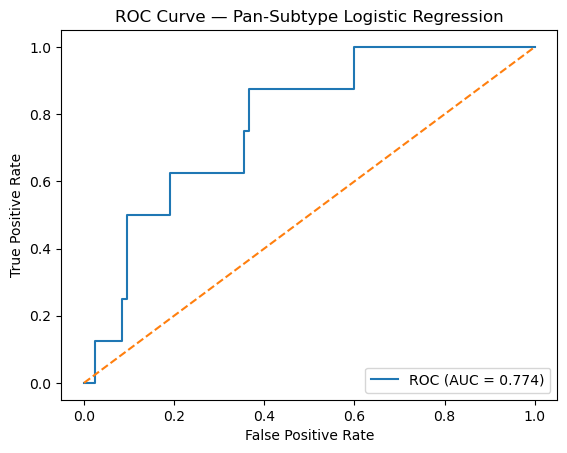

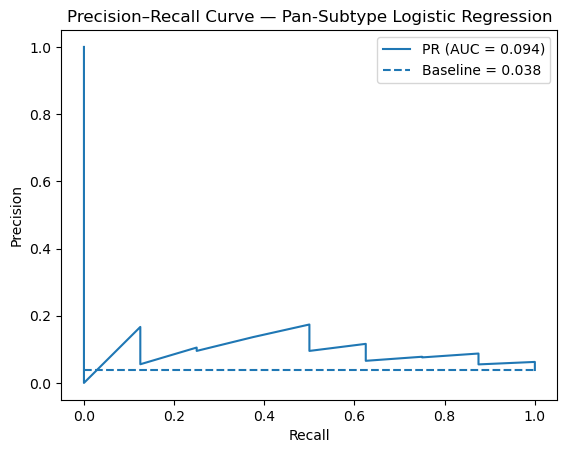

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# ================================
# ROC curve
# ================================
fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Pan-Subtype Logistic Regression")
plt.legend(loc="lower right")
plt.show()

# ================================
# Precision–Recall curve
# ================================
prec, rec, _ = precision_recall_curve(y_true_all, y_prob_all)
pr_auc = auc(rec, prec)

baseline = y_true_all.mean()  # prevalence

plt.figure()
plt.plot(rec, prec, label=f"PR (AUC = {pr_auc:.3f})")
plt.hlines(
    baseline,
    xmin=0,
    xmax=1,
    linestyles="--",
    label=f"Baseline = {baseline:.3f}"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Pan-Subtype Logistic Regression")
plt.legend(loc="upper right")
plt.show()


# Run XGBoost baseline

In [3]:
!pip install xgboost


In [19]:
!pip install xgboost==1.7.6


   ---------------------------------------- 0.0/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/70.9 MB ? eta -:--:--
    --------------------------------------- 1.6/70.9 MB 9.3 MB/s eta 0:00:08
   - -------------------------------------- 3.4/70.9 MB 8.7 MB/s eta 0:00:08
   -- ------------------------------------- 5.0/70.9 MB 8.1 MB/s eta 0:00:09
   --- ------------------------------------ 6.8/70.9 MB 8.6 MB/s eta 0:00:08
   ----- ---------------------------------- 8.9/70.9 MB 8.8 MB/s eta 0:00:08
   ------ --------------------------------- 11.3/70.9 MB 9.0 MB/s eta 0:00:07
   ------- -------------------------------- 13.1/70.9 MB 8.9 MB/s eta 0:00:07
   ------- -------------------------------- 14.2/70.9 MB 8.6 MB/s eta 0:00:07
   --------- ------------------------------ 16.0/70.9 MB 8.4 MB/s eta 0:00:07
   ---------- ----------------------------- 17.8/70.9 MB 8.4 MB/s eta 0:00:07
   ----------- 

In [33]:
ml_df.to_csv(
    r"C:\Users\deep8\breast_cancer_project_folder\ml_df_final.csv",
    index=False
)


In [35]:
import pandas as pd

ml_df = pd.read_csv(
    r"C:\Users\deep8\breast_cancer_project_folder\ml_df_final.csv"
)

print("ml_df loaded")
print(ml_df.shape)
print(ml_df.head())


ml_df loaded
(208, 11)
      drug_id    subtype  n_pathways  mean_pathway_score  max_pathway_score  \
0  CHEMBL1778  LUMINAL_A          16            0.054038           0.153784   
1  CHEMBL1782  LUMINAL_A           5            0.015057           0.045174   
2  CHEMBL1783  LUMINAL_A          29            0.046635           0.153784   
3  CHEMBL1785  LUMINAL_A          10            0.041135           0.153784   
4  CHEMBL1786  LUMINAL_A           2            0.023320           0.045174   

   sum_pathway_score  mean_target_pagerank  max_target_pagerank  \
0           0.864616              0.000302             0.000302   
1           0.075286              0.000091             0.000091   
2           1.352424              0.000768             0.000768   
3           0.411352              0.000129             0.000129   
4           0.046641              0.000024             0.000024   

   n_targets_in_network  network_coverage  final_label  
0                     1                 1 

In [37]:
# ================================
# PHASE 7.5 — Gradient Boosting Baseline (Pan-Subtype, LODO)
# ================================

import numpy as np
import pandas as pd

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

# -----------------------------
# 1) Prepare data
# -----------------------------
df = ml_df.copy()

num_features = [
    "n_pathways",
    "mean_pathway_score",
    "max_pathway_score",
    "sum_pathway_score",
    "mean_target_pagerank",
    "max_target_pagerank",
    "n_targets_in_network",
    "network_coverage"
]

cat_features = ["subtype"]

X = df[num_features + cat_features]
y = df["final_label"].values
groups = df["drug_id"].values  # LODO groups

print("Samples:", len(df))
print("Positives:", y.sum(), "Negatives:", (y == 0).sum())

# -----------------------------
# 2) Preprocessing
# -----------------------------
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features),
        ("cat", OneHotEncoder(drop="first"), cat_features),
    ]
)

# -----------------------------
# 3) Gradient Boosting model
# -----------------------------
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

pipe = Pipeline([
    ("prep", preprocess),
    ("gb", gb)
])

# -----------------------------
# 4) Leave-One-Drug-Out CV
# -----------------------------
logo = LeaveOneGroupOut()

y_true_all, y_prob_all, subtype_all = [], [], []

for train_idx, test_idx in logo.split(X, y, groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    pipe.fit(X_train, y_train)
    prob = pipe.predict_proba(X_test)[:, 1]

    y_true_all.extend(y_test.tolist())
    y_prob_all.extend(prob.tolist())
    subtype_all.extend(X_test["subtype"].tolist())

y_true_all = np.array(y_true_all)
y_prob_all = np.array(y_prob_all)
subtype_all = np.array(subtype_all)

# -----------------------------
# 5) Metrics
# -----------------------------
roc_auc = roc_auc_score(y_true_all, y_prob_all)
prec, rec, _ = precision_recall_curve(y_true_all, y_prob_all)
pr_auc = auc(rec, prec)

print(f"\nGradient Boosting OVERALL ROC-AUC: {roc_auc:.3f}")
print(f"Gradient Boosting OVERALL PR-AUC : {pr_auc:.3f}")

print("\nROC-AUC by subtype:")
for st in np.unique(subtype_all):
    idx = subtype_all == st
    if y_true_all[idx].sum() > 0:
        auc_st = roc_auc_score(y_true_all[idx], y_prob_all[idx])
        print(f"{st:10s}: {auc_st:.3f}")
    else:
        print(f"{st:10s}: NA")


Samples: 208
Positives: 8 Negatives: 200

Gradient Boosting OVERALL ROC-AUC: 0.432
Gradient Boosting OVERALL PR-AUC : 0.059

ROC-AUC by subtype:
HER2      : 0.631
LUMINAL_A : 0.000
LUMINAL_B : 0.774
TNBC      : 0.410


# Extract Logistic Regression feature importance

In [40]:

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# ================================
# 1) Prepare data
# ================================
df = ml_df.copy()

num_features = [
    "n_pathways",
    "mean_pathway_score",
    "max_pathway_score",
    "sum_pathway_score",
    "mean_target_pagerank",
    "max_target_pagerank",
    "n_targets_in_network",
    "network_coverage"
]

cat_features = ["subtype"]

X = df[num_features + cat_features]
y = df["final_label"].values

# ================================
# 2) Build pipeline
# ================================
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first"), cat_features),
    ]
)

lr = LogisticRegression(
    penalty="l2",
    class_weight="balanced",
    solver="liblinear",
    max_iter=500
)

pipe = Pipeline([
    ("prep", preprocess),
    ("lr", lr)
])

# ================================
# 3) Fit on FULL dataset
# ================================
pipe.fit(X, y)

# ================================
# 4) Extract feature names
# ================================
num_names = num_features
cat_names = pipe.named_steps["prep"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(cat_features)

feature_names = np.concatenate([num_names, cat_names])

# ================================
# 5) Extract coefficients
# ================================
coefs = pipe.named_steps["lr"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs,
    "abs_coefficient": np.abs(coefs)
}).sort_values("abs_coefficient", ascending=False)

print("Top contributing features:")
print(coef_df.head(10))

# Optional: save for thesis
coef_df.to_csv(
    r"C:\Users\deep8\breast_cancer_project_folder\logistic_regression_feature_importance.csv",
    index=False
)


Top contributing features:
                 feature  coefficient  abs_coefficient
4   mean_target_pagerank    -2.493518         2.493518
5    max_target_pagerank    -2.493518         2.493518
9      subtype_LUMINAL_B    -1.090422         1.090422
10          subtype_TNBC    -0.422296         0.422296
1     mean_pathway_score    -0.163499         0.163499
8      subtype_LUMINAL_A    -0.161793         0.161793
0             n_pathways    -0.140533         0.140533
3      sum_pathway_score    -0.040585         0.040585
2      max_pathway_score     0.019027         0.019027
6   n_targets_in_network     0.000000         0.000000


In [44]:
# RESULTS PLOTS — STEP 1  
## Feature Correlation Matrix + Heatmap (Pan-Subtype)


Correlation matrix:
                      n_pathways  mean_pathway_score  max_pathway_score  \
n_pathways                  1.00               -0.02               0.07   
mean_pathway_score         -0.02                1.00               0.94   
max_pathway_score           0.07                0.94               1.00   
sum_pathway_score           0.43                0.54               0.68   
mean_target_pagerank        0.78                0.04               0.12   
max_target_pagerank         0.78                0.04               0.12   
n_targets_in_network         NaN                 NaN                NaN   
network_coverage             NaN                 NaN                NaN   

                      sum_pathway_score  mean_target_pagerank  \
n_pathways                         0.43                  0.78   
mean_pathway_score                 0.54                  0.04   
max_pathway_score                  0.68                  0.12   
sum_pathway_score                  1.00     

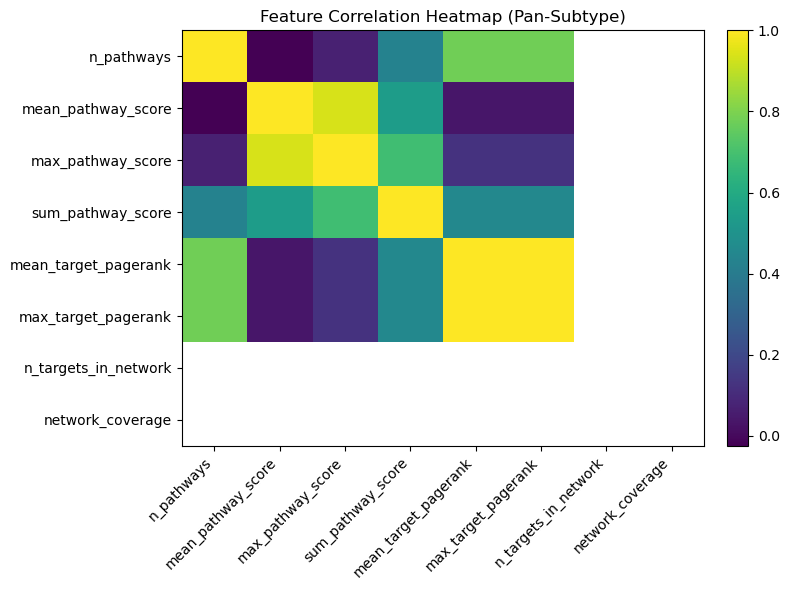

In [42]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Select numeric features only
# -----------------------------
corr_features = [
    "n_pathways",
    "mean_pathway_score",
    "max_pathway_score",
    "sum_pathway_score",
    "mean_target_pagerank",
    "max_target_pagerank",
    "n_targets_in_network",
    "network_coverage"
]

corr_df = ml_df[corr_features]

# -----------------------------
# Compute correlation matrix
# -----------------------------
corr_matrix = corr_df.corr(method="pearson")

print("Correlation matrix:")
print(corr_matrix.round(2))

# -----------------------------
# Plot heatmap (publication style)
# -----------------------------
plt.figure(figsize=(8, 6))
im = plt.imshow(corr_matrix, aspect="auto")

plt.colorbar(im, fraction=0.046, pad=0.04)

plt.xticks(
    ticks=np.arange(len(corr_features)),
    labels=corr_features,
    rotation=45,
    ha="right"
)
plt.yticks(
    ticks=np.arange(len(corr_features)),
    labels=corr_features
)

plt.title("Feature Correlation Heatmap (Pan-Subtype)")
plt.tight_layout()
plt.show()


In [46]:
ml_df["n_targets_in_network"].value_counts()
ml_df["network_coverage"].value_counts()

network_coverage
1    208
Name: count, dtype: int64

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# Drop constant features
corr_df_clean = ml_df[
    [
        "n_pathways",
        "mean_pathway_score",
        "max_pathway_score",
        "sum_pathway_score",
        "mean_target_pagerank",
        "max_target_pagerank"
    ]
]

corr_matrix = corr_df_clean.corr()


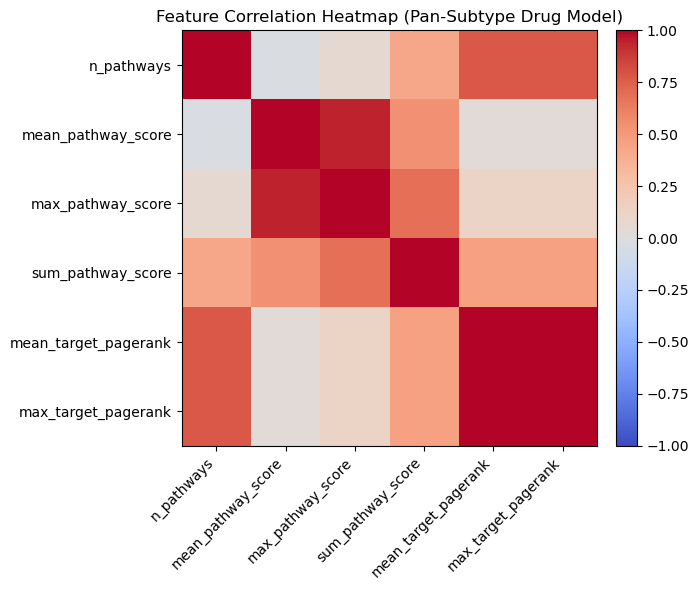

In [50]:
plt.figure(figsize=(7, 6))

im = plt.imshow(
    corr_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(im, fraction=0.046, pad=0.04)

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Feature Correlation Heatmap (Pan-Subtype Drug Model)")
plt.tight_layout()
plt.show()


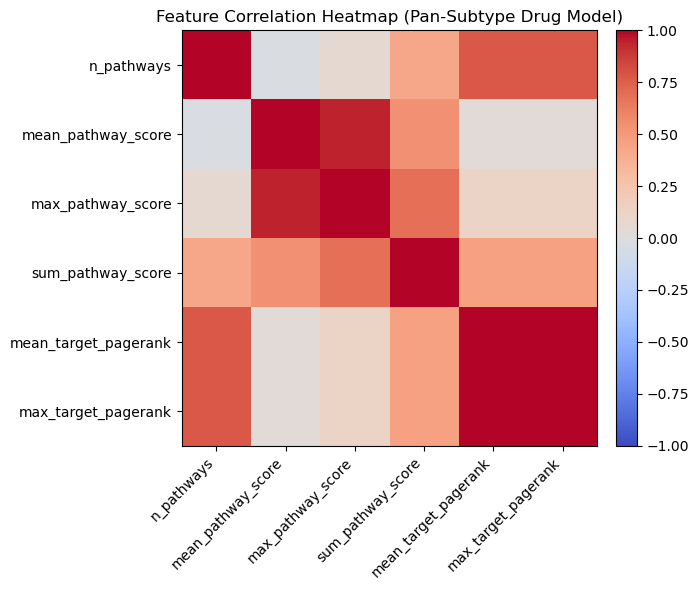

In [52]:

import matplotlib.pyplot as plt
import numpy as np

# ---- recompute (for safety) ----
corr_features = [
    "n_pathways",
    "mean_pathway_score",
    "max_pathway_score",
    "sum_pathway_score",
    "mean_target_pagerank",
    "max_target_pagerank"
]

corr_df = ml_df[corr_features]
corr_matrix = corr_df.corr()

# ---- plot ----
plt.figure(figsize=(7, 6))

im = plt.imshow(
    corr_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(im, fraction=0.046, pad=0.04)

plt.xticks(
    range(len(corr_features)),
    corr_features,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(corr_features)),
    corr_features
)

plt.title("Feature Correlation Heatmap (Pan-Subtype Drug Model)")
plt.tight_layout()

# ---- SAVE at 600 DPI ----
plt.savefig(
    r"C:\Users\deep8\breast_cancer_project_folder\Figure_feature_correlation_heatmap_600dpi.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


Chosen threshold (max F1): 0.9361
Confusion matrix:
 [[198   2]
 [  7   1]]


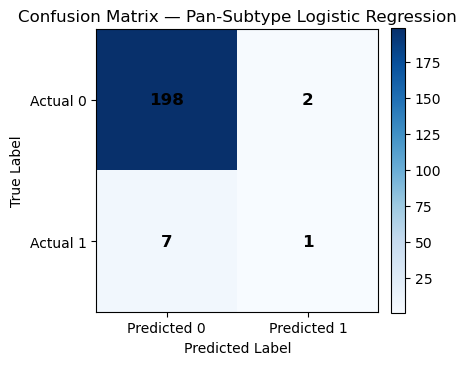

In [54]:

## Confusion Matrix (Pan-Subtype Logistic Regression, Publication-Ready)


import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_recall_curve

# ---------------------------------
# 1. Recompute optimal threshold
# ---------------------------------
prec, rec, thr = precision_recall_curve(y_true_all, y_prob_all)

f1_scores = (2 * prec * rec) / (prec + rec + 1e-9)
best_thr = thr[np.nanargmax(f1_scores[:-1])]

print("Chosen threshold (max F1):", round(best_thr, 4))

# ---------------------------------
# 2. Confusion matrix
# ---------------------------------
y_pred = (y_prob_all >= best_thr).astype(int)
cm = confusion_matrix(y_true_all, y_pred)

print("Confusion matrix:\n", cm)

# ---------------------------------
# 3. Plot confusion matrix
# ---------------------------------
plt.figure(figsize=(4.5, 4))

im = plt.imshow(cm, cmap="Blues")
plt.colorbar(im, fraction=0.046, pad=0.04)

plt.xticks([0, 1], ["Predicted 0", "Predicted 1"])
plt.yticks([0, 1], ["Actual 0", "Actual 1"])

# Annotate cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center", va="center",
            fontsize=12, fontweight="bold"
        )

plt.title("Confusion Matrix — Pan-Subtype Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

In [62]:
import numpy as np
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# -----------------------------
# Prepare data
# -----------------------------
df = ml_df.copy()

num_features = [
    "n_pathways",
    "mean_pathway_score",
    "max_pathway_score",
    "sum_pathway_score",
    "mean_target_pagerank",
    "max_target_pagerank",
    "n_targets_in_network",
    "network_coverage"
]
cat_features = ["subtype"]

X = df[num_features + cat_features]
y = df["final_label"].values
groups = df["drug_id"].values

preprocess = ColumnTransformer(
    [
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first"), cat_features),
    ]
)

lr = LogisticRegression(
    penalty="l2",
    class_weight="balanced",
    solver="liblinear",
    max_iter=500
)

pipe = Pipeline([
    ("prep", preprocess),
    ("lr", lr)
])

logo = LeaveOneGroupOut()

y_true_lr, y_prob_lr = [], []

for train_idx, test_idx in logo.split(X, y, groups):
    pipe.fit(X.iloc[train_idx], y[train_idx])
    prob = pipe.predict_proba(X.iloc[test_idx])[:, 1]
    y_true_lr.extend(y[test_idx])
    y_prob_lr.extend(prob)

y_true_lr = np.array(y_true_lr)
y_prob_lr = np.array(y_prob_lr)

print("Logistic Regression predictions ready")


Logistic Regression predictions ready


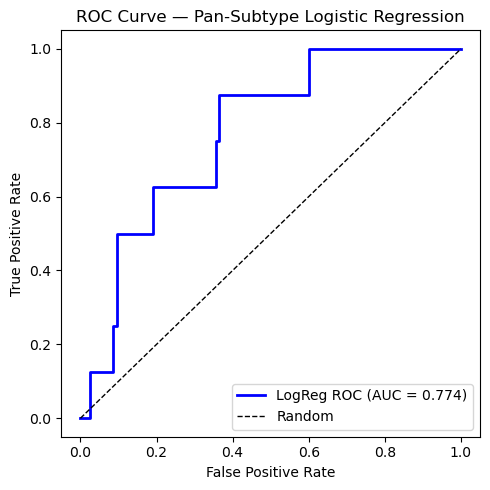

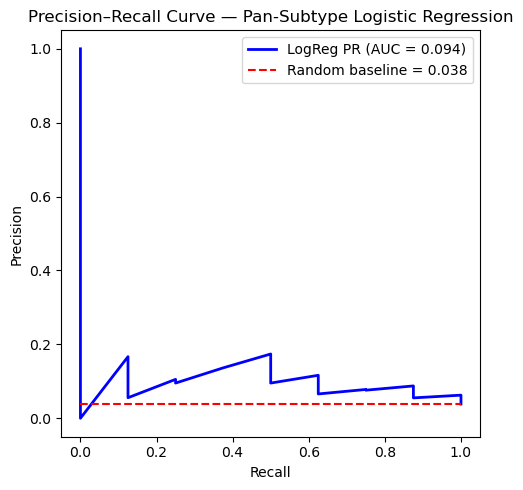

In [64]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# ======================
# ROC Curve
# ======================
fpr, tpr, _ = roc_curve(y_true_lr, y_prob_lr)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, color="blue", linewidth=2,
         label=f"LogReg ROC (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], color="black", linestyle="--", linewidth=1,
         label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Pan-Subtype Logistic Regression")
plt.legend()
plt.tight_layout()


# ======================
# Precision–Recall Curve
# ======================
prec, rec, _ = precision_recall_curve(y_true_lr, y_prob_lr)
pr_auc = auc(rec, prec)
baseline = y_true_lr.mean()

plt.figure(figsize=(5,5))
plt.plot(rec, prec, color="blue", linewidth=2,
         label=f"LogReg PR (AUC = {pr_auc:.3f})")
plt.hlines(baseline, 0, 1, colors="red", linestyles="--",
           label=f"Random baseline = {baseline:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Pan-Subtype Logistic Regression")
plt.legend()
plt.tight_layout()



In [66]:
plt.savefig(
    r"C:\Users\deep8\breast_cancer_project_folder\Figure_ROC_LogReg_600dpi.png",
    dpi=600
)
plt.show()
plt.savefig(
    r"C:\Users\deep8\breast_cancer_project_folder\Figure_PR_LogReg_600dpi.png",
    dpi=600
)
plt.show()


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

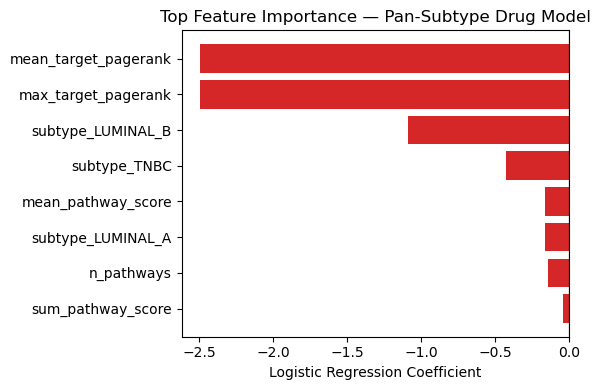

In [68]:

## Feature Importance Bar Plot (Logistic Regression, Publication-Ready)

import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load feature importance
# -----------------------------
coef_df = pd.read_csv(
    r"C:\Users\deep8\breast_cancer_project_folder\logistic_regression_feature_importance.csv"
)

# Select top features by absolute coefficient
top_k = 8
top_df = coef_df.sort_values(
    "abs_coefficient", ascending=False
).head(top_k)

# -----------------------------
# Plot bar chart
# -----------------------------
plt.figure(figsize=(6, 4))

colors = ["#1f77b4" if c > 0 else "#d62728" for c in top_df["coefficient"]]

plt.barh(
    top_df["feature"],
    top_df["coefficient"],
    color=colors
)

plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Logistic Regression Coefficient")
plt.title("Top Feature Importance — Pan-Subtype Drug Model")

plt.gca().invert_yaxis()  # highest importance on top
plt.tight_layout()



In [70]:
# -----------------------------
# Save at 600 DPI
# -----------------------------
plt.savefig(
    r"C:\Users\deep8\breast_cancer_project_folder\Figure_feature_importance_600dpi.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


<Figure size 640x480 with 0 Axes>

Precision@K values:
Precision@5: 0.000
Precision@10: 0.100
Precision@20: 0.100


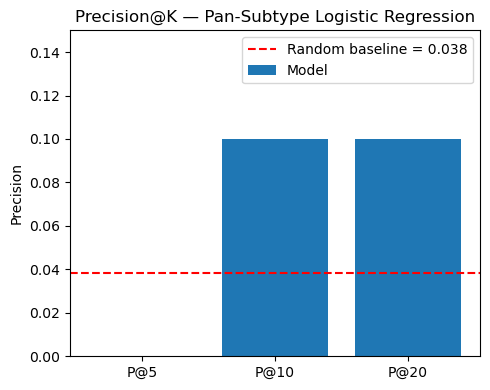

In [72]:

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Precision@K function
# -----------------------------
def precision_at_k(y_true, y_score, k):
    k = min(k, len(y_true))
    idx = np.argsort(y_score)[::-1][:k]
    return y_true[idx].sum() / k

# -----------------------------
# Compute Precision@K
# -----------------------------
Ks = [5, 10, 20]
precisions = [precision_at_k(y_true_lr, y_prob_lr, k) for k in Ks]

baseline = y_true_lr.mean()  # random expectation

print("Precision@K values:")
for k, p in zip(Ks, precisions):
    print(f"Precision@{k}: {p:.3f}")

# -----------------------------
# Plot bar chart
# -----------------------------
plt.figure(figsize=(5, 4))

plt.bar(
    [f"P@{k}" for k in Ks],
    precisions,
    color="#1f77b4",
    label="Model"
)

plt.axhline(
    baseline,
    color="red",
    linestyle="--",
    label=f"Random baseline = {baseline:.3f}"
)

plt.ylabel("Precision")
plt.title("Precision@K — Pan-Subtype Logistic Regression")
plt.ylim(0, max(precisions + [baseline]) + 0.05)
plt.legend()
plt.tight_layout()



In [74]:
# -----------------------------
# Save at 600 DPI
# -----------------------------
plt.savefig(
    r"C:\Users\deep8\breast_cancer_project_folder\Figure_Precision_at_K_600dpi.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


<Figure size 640x480 with 0 Axes>

Positive samples: 8
Negative samples: 200


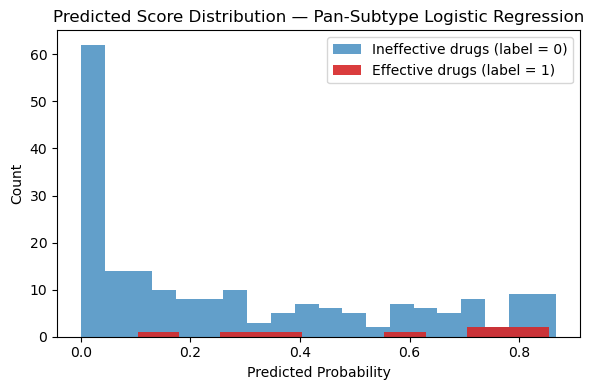

In [76]:

## Predicted Score Distribution (Positives vs Negatives)


import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Separate scores
# -----------------------------
pos_scores = y_prob_lr[y_true_lr == 1]
neg_scores = y_prob_lr[y_true_lr == 0]

print("Positive samples:", len(pos_scores))
print("Negative samples:", len(neg_scores))

# -----------------------------
# Plot score distribution
# -----------------------------
plt.figure(figsize=(6, 4))

plt.hist(
    neg_scores,
    bins=20,
    alpha=0.7,
    label="Ineffective drugs (label = 0)",
    color="#1f77b4"
)

plt.hist(
    pos_scores,
    bins=10,
    alpha=0.9,
    label="Effective drugs (label = 1)",
    color="#d62728"
)

plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Predicted Score Distribution — Pan-Subtype Logistic Regression")
plt.legend()
plt.tight_layout()



In [78]:
# -----------------------------
# Save at 600 DPI
# -----------------------------
plt.savefig(
    r"C:\Users\deep8\breast_cancer_project_folder\Figure_score_distribution_600dpi.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


<Figure size 640x480 with 0 Axes>

In [80]:

## 📊 Table X. Top Predicted Candidate Drugs by Breast Cancer Subtype

### Columns (keep exactly this order)
#| Drug (ChEMBL ID) | Drug Name | Subtype | Predicted Score | Rank | Primary Target(s) | Key Pathway(s) | Evidence Type | Repurposing Rationale |


## 🧪 Step 1 — Generate ranked candidates from Logistic Regression


import pandas as pd
import numpy as np

# ----------------------------------
# Build prediction dataframe
# ----------------------------------
pred_df = ml_df.copy()
pred_df["predicted_score"] = y_prob_lr

# Rank within each subtype
pred_df["rank_within_subtype"] = (
    pred_df.groupby("subtype")["predicted_score"]
    .rank(ascending=False, method="dense")
)

# Select top N per subtype
TOP_N = 5
top_candidates = pred_df[pred_df["rank_within_subtype"] <= TOP_N]

# Sort nicely
top_candidates = top_candidates.sort_values(
    ["subtype", "rank_within_subtype"]
)

print(top_candidates[
    ["drug_id", "subtype", "predicted_score", "rank_within_subtype"]
])


        drug_id    subtype  predicted_score  rank_within_subtype
122  CHEMBL1854       HER2         0.853690                  1.0
128  CHEMBL1916       HER2         0.817789                  2.0
106  CHEMBL1778       HER2         0.763288                  3.0
123  CHEMBL1855       HER2         0.760288                  4.0
153  CHEMBL2438       HER2         0.735944                  5.0
40   CHEMBL2057  LUMINAL_A         0.867542                  1.0
18   CHEMBL1854  LUMINAL_A         0.823207                  2.0
41   CHEMBL2106  LUMINAL_A         0.816726                  3.0
16   CHEMBL1843  LUMINAL_A         0.808352                  4.0
38   CHEMBL2045  LUMINAL_A         0.797559                  5.0
56   CHEMBL1786  LUMINAL_B         0.867308                  1.0
54   CHEMBL1783  LUMINAL_B         0.858607                  2.0
90   CHEMBL2040  LUMINAL_B         0.850366                  3.0
98   CHEMBL2156  LUMINAL_B         0.831643                  4.0
88   CHEMBL2002  LUMINAL_

In [82]:
drug_map = pd.read_csv(
    r"C:\Users\deep8\breast_cancer_project_folder\Phase6_ChEMBL_Drug_Name_Map.csv"
)

top_candidates = top_candidates.merge(
    drug_map,
    left_on="drug_id",
    right_on="chembl_id",
    how="left"
)

top_candidates[[
    "drug_id", "drug_name", "subtype",
    "predicted_score", "rank_within_subtype"
]]


,drug_id,drug_name,subtype,predicted_score,rank_within_subtype
0,CHEMBL1854,NaN,HER2,0.853690,1.0
1,CHEMBL1916,NaN,HER2,0.817789,2.0
2,CHEMBL1778,NaN,HER2,0.763288,3.0
3,CHEMBL1855,NaN,HER2,0.760288,4.0
4,CHEMBL2438,NaN,HER2,0.735944,5.0
5,CHEMBL2057,NaN,LUMINAL_A,0.867542,1.0
6,CHEMBL1854,NaN,LUMINAL_A,0.823207,2.0
7,CHEMBL2106,NaN,LUMINAL_A,0.816726,3.0
8,CHEMBL1843,NaN,LUMINAL_A,0.808352,4.0
9,CHEMBL2045,NaN,LUMINAL_A,0.797559,5.0


In [84]:
candidate_table = top_candidates[[
    "drug_id",
    "drug_name",
    "subtype",
    "predicted_score",
    "rank_within_subtype"
]].copy()

candidate_table = candidate_table.rename(columns={
    "drug_id": "Drug (ChEMBL ID)",
    "drug_name": "Drug Name",
    "subtype": "Subtype",
    "predicted_score": "Predicted Score",
    "rank_within_subtype": "Rank"
})

# Add biological annotation columns (to be curated)
candidate_table["Primary Target(s)"] = "—"
candidate_table["Key Pathway(s)"] = "—"
candidate_table["Evidence Type"] = "Computational prediction"
candidate_table["Repurposing Rationale"] = "Subtype-specific network/pathway targeting"

candidate_table


,Drug (ChEMBL ID),Drug Name,Subtype,Predicted Score,Rank,Primary Target(s),Key Pathway(s),Evidence Type,Repurposing Rationale
0,CHEMBL1854,NaN,HER2,0.853690,1.0,—,—,Computational prediction,Subtype-specific network/pathway targeting
1,CHEMBL1916,NaN,HER2,0.817789,2.0,—,—,Computational prediction,Subtype-specific network/pathway targeting
2,CHEMBL1778,NaN,HER2,0.763288,3.0,—,—,Computational prediction,Subtype-specific network/pathway targeting
3,CHEMBL1855,NaN,HER2,0.760288,4.0,—,—,Computational prediction,Subtype-specific network/pathway targeting
4,CHEMBL2438,NaN,HER2,0.735944,5.0,—,—,Computational prediction,Subtype-specific network/pathway targeting
5,CHEMBL2057,NaN,LUMINAL_A,0.867542,1.0,—,—,Computational prediction,Subtype-specific network/pathway targeting
6,CHEMBL1854,NaN,LUMINAL_A,0.823207,2.0,—,—,Computational prediction,Subtype-specific network/pathway targeting
7,CHEMBL2106,NaN,LUMINAL_A,0.816726,3.0,—,—,Computational prediction,Subtype-specific network/pathway targeting
8,CHEMBL1843,NaN,LUMINAL_A,0.808352,4.0,—,—,Computational prediction,Subtype-specific network/pathway targeting
9,CHEMBL2045,NaN,LUMINAL_A,0.797559,5.0,—,—,Computational prediction,Subtype-specific network/pathway targeting


In [104]:

# Check which drug_ids are missing from drug_map

pred_drugs = set(candidate_table["Drug (ChEMBL ID)"])
map_drugs = set(drug_map["chembl_id"])

missing = pred_drugs - map_drugs

print("Total predicted drugs:", len(pred_drugs))
print("Drugs missing in drug_map:", len(missing))
print("Missing examples:", list(missing)[:5])


Total predicted drugs: 18
Drugs missing in drug_map: 18
Missing examples: ['CHEMBL2109', 'CHEMBL1778', 'CHEMBL2045', 'CHEMBL2156', 'CHEMBL1855']


In [108]:

import pandas as pd

# Load drug-pathway mapping
drug_pathway = pd.read_csv(
    r"C:\Users\deep8\breast_cancer_project_folder\Drug_Pathways.csv"
)

print("Drug-Pathway file shape:", drug_pathway.shape)
print(drug_pathway.head())

print("\nUnique drugs in pathway file:", drug_pathway["drug"].nunique())


Drug-Pathway file shape: (7901, 3)
         drug    reactome_id                         pathway_name
0  CHEMBL1778  R-HSA-1280215  Cytokine Signaling in Immune system
1  CHEMBL1778   R-HSA-162582                  Signal Transduction
2  CHEMBL1778   R-HSA-168256                        Immune System
3  CHEMBL1778   R-HSA-212436        Generic Transcription Pathway
4  CHEMBL1778   R-HSA-449147            Signaling by Interleukins

Unique drugs in pathway file: 512


In [110]:

# ----------------------------------
# Aggregate pathways per drug
# ----------------------------------

# Group pathways by drug
drug_to_pathways = (
    drug_pathway
    .groupby("drug")["pathway_name"]
    .apply(lambda x: "; ".join(x.value_counts().index[:3]))
    .reset_index()
)

drug_to_pathways.columns = ["Drug (ChEMBL ID)", "Key Pathway(s)"]

print(drug_to_pathways.head())

# ----------------------------------
# Merge into candidate table
# ----------------------------------

candidate_table = candidate_table.drop(columns=["Key Pathway(s)"])

candidate_table = candidate_table.merge(
    drug_to_pathways,
    on="Drug (ChEMBL ID)",
    how="left"
)

# Fill missing pathway info
candidate_table["Key Pathway(s)"] = (
    candidate_table["Key Pathway(s)"]
    .fillna("Pathway data not available")
)

# ----------------------------------
# View final table
# ----------------------------------
candidate_table


  Drug (ChEMBL ID)                                     Key Pathway(s)
0       CHEMBL1778  Cytokine Signaling in Immune system; Signal Tr...
1       CHEMBL1782  Metabolism; Regulation of cholesterol biosynth...
2       CHEMBL1783  Hemostasis; VEGFR2 mediated cell proliferation...
3       CHEMBL1785  Developmental Biology; Signal Transduction; Si...
4       CHEMBL1786  Metabolism; Inositol phosphate metabolism; Syn...


,Drug (ChEMBL ID),Drug Name,Subtype,Predicted Score,Rank,Primary Target(s),Evidence Type,Repurposing Rationale,Key Pathway(s)
0,CHEMBL1854,NaN,HER2,0.853690,1.0,—,Computational prediction,Subtype-specific network/pathway targeting,Signal Transduction; Signaling by GPCR; Class ...
1,CHEMBL1916,NaN,HER2,0.817789,2.0,—,Computational prediction,Subtype-specific network/pathway targeting,Hemostasis; Metabolism of proteins; Platelet a...
2,CHEMBL1778,NaN,HER2,0.763288,3.0,—,Computational prediction,Subtype-specific network/pathway targeting,Cytokine Signaling in Immune system; Signal Tr...
3,CHEMBL1855,NaN,HER2,0.760288,4.0,—,Computational prediction,Subtype-specific network/pathway targeting,Signal Transduction; Signaling by GPCR; Class ...
4,CHEMBL2438,NaN,HER2,0.735944,5.0,—,Computational prediction,Subtype-specific network/pathway targeting,Innate Immune System; Immune System; Neutrophi...
5,CHEMBL2057,NaN,LUMINAL_A,0.867542,1.0,—,Computational prediction,Subtype-specific network/pathway targeting,Metabolism; Tetrahydrobiopterin (BH4) synthesi...
6,CHEMBL1854,NaN,LUMINAL_A,0.823207,2.0,—,Computational prediction,Subtype-specific network/pathway targeting,Signal Transduction; Signaling by GPCR; Class ...
7,CHEMBL2106,NaN,LUMINAL_A,0.816726,3.0,—,Computational prediction,Subtype-specific network/pathway targeting,Hemostasis; Platelet degranulation ; Metabolism
8,CHEMBL1843,NaN,LUMINAL_A,0.808352,4.0,—,Computational prediction,Subtype-specific network/pathway targeting,Metabolism; Metabolism of amine-derived hormon...
9,CHEMBL2045,NaN,LUMINAL_A,0.797559,5.0,—,Computational prediction,Subtype-specific network/pathway targeting,Developmental Biology; Digestion of dietary ca...


In [112]:
candidate_table.to_csv(
    r"C:\Users\deep8\breast_cancer_project_folder\Table_Top_Candidate_Drugs_Final.csv",
    index=False
)


In [114]:

import pandas as pd
import textwrap

# -------------------------------
# 1. Copy table
# -------------------------------
word_table = candidate_table.copy()

# -------------------------------
# 2. Clean & format columns
# -------------------------------
word_table["Predicted Score"] = word_table["Predicted Score"].round(3)

# Shorten long pathway text (Word readability)
def shorten(text, width=60):
    if pd.isna(text):
        return text
    return "\n".join(textwrap.wrap(text, width=width))

word_table["Key Pathway(s)"] = word_table["Key Pathway(s)"].apply(shorten)

# -------------------------------
# 3. Reorder columns (paper order)
# -------------------------------
word_table = word_table[[
    "Drug (ChEMBL ID)",
    "Subtype",
    "Predicted Score",
    "Rank",
    "Primary Target(s)",
    "Key Pathway(s)",
    "Evidence Type",
    "Repurposing Rationale"
]]

# -------------------------------
# 4. Sort nicely
# -------------------------------
word_table = word_table.sort_values(
    ["Subtype", "Rank"]
).reset_index(drop=True)

# -------------------------------
# 5. Save Word-ready Excel
# -------------------------------
output_path = r"C:\Users\deep8\breast_cancer_project_folder\Table_Top_Candidate_Drugs_WORD_READY.xlsx"

word_table.to_excel(output_path, index=False)

print("✅ Word-ready table saved at:")
print(output_path)

word_table.head()


✅ Word-ready table saved at:
C:\Users\deep8\breast_cancer_project_folder\Table_Top_Candidate_Drugs_WORD_READY.xlsx


,Drug (ChEMBL ID),Subtype,Predicted Score,Rank,Primary Target(s),Key Pathway(s),Evidence Type,Repurposing Rationale
0,CHEMBL1854,HER2,0.854,1.0,—,Signal Transduction; Signaling by GPCR; Class ...,Computational prediction,Subtype-specific network/pathway targeting
1,CHEMBL1916,HER2,0.818,2.0,—,Hemostasis; Metabolism of proteins; Platelet a...,Computational prediction,Subtype-specific network/pathway targeting
2,CHEMBL1778,HER2,0.763,3.0,—,Cytokine Signaling in Immune system; Signal Tr...,Computational prediction,Subtype-specific network/pathway targeting
3,CHEMBL1855,HER2,0.760,4.0,—,Signal Transduction; Signaling by GPCR; Class ...,Computational prediction,Subtype-specific network/pathway targeting
4,CHEMBL2438,HER2,0.736,5.0,—,Innate Immune System; Immune System; Neutrophi...,Computational prediction,Subtype-specific network/pathway targeting
